### About the Data:
age: age of the insured person (numeric)                                          
sex: gender of the insured person (categorical: male/female)                                     
bmi: body mass index of the insured person (numeric)                                               
children: number of children covered by the insurance plan (numeric)                                  
smoker: whether or not the insured person is a smoker (categorical: yes/no)                                  
region: region where the insured person resides (categorical: northeast/northwest/southeast/southwest)                                            
charges: the insurance charges/costs billed to the insured person (numeric)                                                         

In [314]:
# Import Necessary Packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### 1. Import Data

In [315]:
medical_df = pd.read_csv('Insurance.csv')

### 2. Cleaning the data

In [316]:
medical_df.shape

(1338, 7)

In [317]:
medical_df.head(10)

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
5,31,female,25.740,0,no,southeast,3756.62160
6,46,female,33.440,1,no,southeast,8240.58960
7,37,female,27.740,3,no,northwest,7281.50560
8,37,male,29.830,2,no,northeast,6406.41070
9,60,female,25.840,0,no,northwest,28923.13692


In [318]:
medical_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [319]:
# Check the unique values of each column to identify inconsistencies, invalid entries, missing values, duplicate categories, and formatting issues.

# medical_df['age'].value_counts()
# medical_df['sex'].value_counts()
# medical_df['bmi'].value_counts()
medical_df['children'].value_counts()
# medical_df['smoker'].value_counts()
# medical_df['region'].value_counts()
# medical_df['charges'].value_counts()

# No anomalies were found in any column, so no data cleaning is required.

0    574
1    324
2    240
3    157
4     25
5     18
Name: children, dtype: int64

In [320]:
medical_df_copy=medical_df.copy()

### 3. Exploratory Data Analysis

In [321]:
medical_df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


<Figure size 300x300 with 0 Axes>

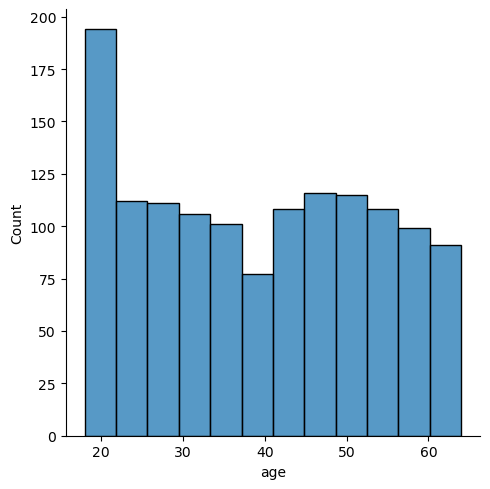

In [322]:
plt.figure(figsize=(3,3))
sns.displot(data=medical_df,x='age')
plt.show()

<Figure size 300x300 with 0 Axes>

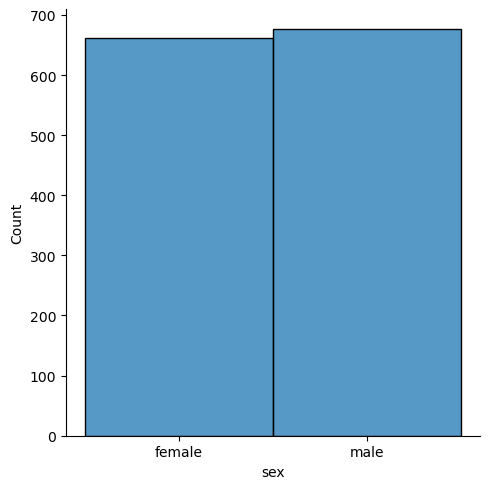

In [323]:
plt.figure(figsize=(3,3))
sns.displot(data=medical_df,x='sex',kind='hist')
plt.show()

<Figure size 400x400 with 0 Axes>

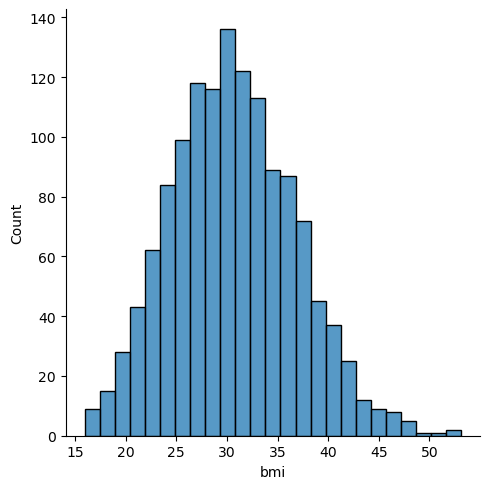

In [324]:
plt.figure(figsize=(4,4))
sns.displot(data=medical_df,x='bmi')
plt.xlabel('bmi') 
plt.ylabel('Count')
plt.show()

In [325]:
medical_df['children'].value_counts()

0    574
1    324
2    240
3    157
4     25
5     18
Name: children, dtype: int64

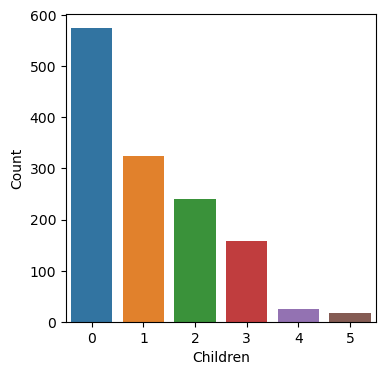

In [326]:
plt.figure(figsize=(4,4))
sns.countplot(medical_df,x='children')
plt.xlabel('Children') 
plt.ylabel('Count')
plt.show()

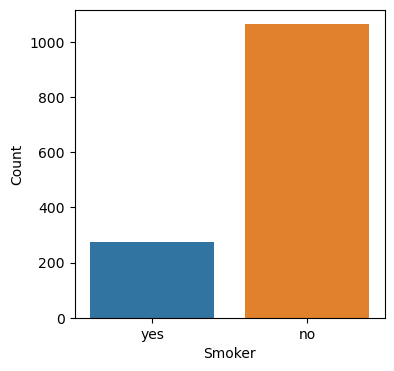

In [327]:
plt.figure(figsize=(4,4))
sns.countplot(data=medical_df,x='smoker')
plt.xlabel('Smoker') 
plt.ylabel('Count')
plt.show()

In [328]:
medical_df['region'].value_counts()

southeast    364
southwest    325
northwest    325
northeast    324
Name: region, dtype: int64

In [329]:
medical_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


### 4. Seperate Dependant and Independant Feature

In [330]:
x = medical_df.drop('charges',axis=1)
y = medical_df['charges']

### 5. Train Test Split

In [331]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.1, random_state=42)

### 6. Preprocessing-convert categorical variables into numerical values

In [332]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
column_transformer = ColumnTransformer(
    transformers=[
        ('ohe', OneHotEncoder(sparse=False),['sex','smoker','region'])
        ],
    remainder='passthrough'
)                        ### Keep the numeric column as-is


### 7. Model Selection

In [333]:
from sklearn.linear_model import LinearRegression,Ridge,Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor,GradientBoostingRegressor,AdaBoostRegressor,ExtraTreesRegressor
from xgboost import XGBRegressor


lr = LinearRegression()
lr_lasso = Lasso()
lr_ridge = Ridge()
dtr=DecisionTreeRegressor()
knr=KNeighborsRegressor()
svr=SVR()
rfr=RandomForestRegressor()
gbr=GradientBoostingRegressor()
abr=AdaBoostRegressor()
etr=ExtraTreesRegressor()
xgb=XGBRegressor()
r_names={'lr':lr,'lr_lasso':lr_lasso,'lr_ridge':lr_ridge,'dtr':dtr,'knr':knr,'svr':svr,'rfr':rfr,'gbr':gbr,'abr':abr,'etr':etr,'xgb':xgb}

### 8. Model Evaluation

In [334]:
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
def get_metrics(r,x_train,y_train,x_test,y_test):
     pipe = Pipeline([('CT', column_transformer),('Model',r)])
     pipe.fit(x_train,y_train)
     y_pred = pipe.predict(x_test)
    
     MSE = mean_squared_error(y_test, y_pred)
     RMSE = np.sqrt(MSE)
     MAE = mean_absolute_error(y_test, y_pred)
     R2 = r2_score(y_test, y_pred)
     return MSE,RMSE,MAE,R2
 
 
all_MSE = []
all_RMSE = []
all_MAE = []
all_R2 = []
for name,r in r_names.items():
    current_MSE,current_RMSE,current_MAE,current_R2 = get_metrics(r,x_train,y_train,x_test,y_test)
    
    all_MSE.append(current_MSE)
    all_RMSE.append(current_RMSE)
    all_MAE.append(current_MAE)
    all_R2.append(current_R2) 
metrics_df = pd.DataFrame({'Algorithm':r_names.keys(),'MSE':all_MSE,'RMSE':all_RMSE,'MAE':all_MAE,'R2':all_R2}).sort_values('R2',ascending=False)
metrics_df

c:\Users\hp\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\preprocessing\_encoders.py:868: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(
c:\Users\hp\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\preprocessing\_encoders.py:868: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(
c:\Users\hp\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\preprocessing\_encoders.py:868: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(
c:\Users\hp\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\preprocessing\_encoder

,Algorithm,MSE,RMSE,MAE,R2
7,gbr,1.853240e+07,4304.927047,2385.663625,0.865664
6,rfr,2.243479e+07,4736.538247,2512.248717,0.837376
10,xgb,2.390080e+07,4888.844552,2719.483710,0.826750
8,abr,2.529297e+07,5029.211277,4098.014528,0.816658
9,etr,2.621783e+07,5120.335285,2408.567631,0.809954
2,lr_ridge,3.226130e+07,5679.902800,4092.917991,0.766147
0,lr,3.227585e+07,5681.183886,4087.534347,0.766041
1,lr_lasso,3.227675e+07,5681.263405,4088.260733,0.766035
3,dtr,3.967492e+07,6298.803098,2997.487802,0.712407
4,knr,8.490351e+07,9214.310255,6388.832957,0.384558


### 9. After Comparison-Selected Model

In [335]:
# LinearRegression gives overall best result
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
column_transformer = ColumnTransformer(
    transformers=[
        ('ohe', OneHotEncoder(sparse=False),['sex','smoker','region'])
        ],
    remainder='passthrough'
) 
from sklearn.linear_model import LinearRegression
lr= LinearRegression()
from sklearn.pipeline import Pipeline
pipe = Pipeline([('CT', column_transformer),('Model', lr)])
pipe.fit(x_train,y_train)



c:\Users\hp\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\preprocessing\_encoders.py:868: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


Pipeline(steps=[('CT',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ohe',
                                                  OneHotEncoder(sparse=False),
                                                  ['sex', 'smoker',
                                                   'region'])])),
                ('Model', LinearRegression())])

### 10. Prediction System

In [336]:
# Input data as dictionary with column names
input_data = {
    'age': 2,
    'sex': "female",
    'bmi': 40.020,
    'children': 5,
    'smoker': "no",
    'region': "southeast"
}

# Convert to DataFrame (1 row, with column names)
input_df = pd.DataFrame([input_data])

# Predict using pipeline
prediction = pipe.predict(input_df)
print(prediction)

[3389.02689819]


In [337]:
import pickle
pickle.dump(pipe,open('model.pkl','wb'))

In [338]:
# import pickle
# pickle.load(open('model.pkl','rb'))